In [1]:
# Run parameters (course reproducibility rule: state parameters this assignment references)
SID4 = 1605
SEED = 1605

# Explicit seeding immediately after declaring SEED, applied to every RNG this notebook touches.
import random
import numpy as np
import torch

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if hasattr(torch.mps, "manual_seed"):
    # torch.mps.manual_seed exists in this torch version (2.11.0) -- verified empirically below.
    torch.mps.manual_seed(SEED)

print("SID4:", SID4)
print("SEED:", SEED)
print("torch.mps has manual_seed:", hasattr(torch.mps, "manual_seed"))


SID4: 1605
SEED: 1605
torch.mps has manual_seed: True


# PyTorch Training Optimization Techniques

This notebook explores five practical techniques for optimizing PyTorch training:

1. Tensor Creation (CPU vs GPU)
2. Weight Initialization
3. Activation Checkpointing
4. Gradient Accumulation
5. Mixed Precision Training

**Hardware note:** This machine has **no CUDA GPU** (`torch.cuda.is_available()` is `False`). It is Apple Silicon with **MPS** (`torch.backends.mps.is_available()` is `True`). Throughout this notebook, **MPS stands in for "the GPU"** wherever the assignment refers to CUDA/GPU behavior. Memory-measurement APIs differ from CUDA's:

- CUDA has `torch.cuda.memory_allocated()` / `torch.cuda.max_memory_allocated()` (an exact running peak since the last reset).
- MPS (in this torch version, 2.11.0) only exposes `torch.mps.current_allocated_memory()` (a snapshot of tensor memory currently allocated by the MPS allocator) and `torch.mps.driver_allocated_memory()` (total memory the Metal driver has reserved, including its internal cache — always ≥ `current_allocated_memory()`). **There is no `torch.mps.max_memory_allocated()` in this API** — no exact running-peak equivalent. We approximate a "peak" by sampling `current_allocated_memory()` at specific points during the forward/backward pass (see Section 3), which is the closest practical equivalent available.
- Where GPU memory isn't the relevant axis (e.g. weight initialization, gradient accumulation), we also report CPU process RSS via `psutil` for completeness.

All five sections reuse **one shared model architecture, one shared synthetic dataset, and one shared training-step function**, defined once in the Setup section below. Each section only toggles its own knob (init scheme, checkpointing on/off, accumulation steps, precision mode) so comparisons are apples-to-apples. Random seeds are fixed for reproducibility.


In [2]:
import time
import gc
import os
import copy
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.utils.checkpoint as ckpt_util
import psutil

warnings.filterwarnings("ignore")

# SEED is already declared and applied (random/numpy/torch/mps) in the first cell above.
# Re-apply it here too so this cell is safe to re-run on its own without losing determinism.
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if hasattr(torch.mps, "manual_seed"):
    torch.mps.manual_seed(SEED)

print("torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("MPS available :", torch.backends.mps.is_available())
print("MPS built     :", torch.backends.mps.is_built())


torch version: 2.11.0
CUDA available: False
MPS available : True
MPS built     : True


## Shared Setup

- **Model:** `DeepMLP` — a residual MLP made of stacked `Block` modules (Linear -> GELU -> Linear -> residual add -> LayerNorm), similar in spirit to a Transformer encoder's feed-forward sub-block but simpler and faster. Depth is configurable so we can make it "deep enough" for activation checkpointing to matter.
- **Dataset:** synthetic classification task — `torch.randn` features, labels generated as `argmax(X @ random_projection)` so there's real (learnable) signal without any external download.
- **Constants used across every comparison:** `BATCH_SIZE = 64`, `STEPS = 50`, SGD optimizer, fixed seed per run so every variant sees the *same* sequence of mini-batches.
- Section 3 (activation checkpointing) additionally uses a **larger** instantiation of the same `DeepMLP` class (bigger hidden size / depth / batch) — this is called out explicitly there — because the default-sized model is too small for MPS's caching allocator to show a visible memory difference. Every other section uses the exact shared-size model.


In [3]:
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    return torch.device("cpu")

DEVICE = get_device()
print("Using device:", DEVICE)

# ---- shared constants ----
INPUT_DIM = 256
HIDDEN_DIM = 512
NUM_CLASSES = 10
NUM_BLOCKS = 8
N_SAMPLES = 4096
BATCH_SIZE = 64
STEPS = 50
LR = 0.01


def make_dataset(n=N_SAMPLES, d=INPUT_DIM, c=NUM_CLASSES, seed=SEED):
    g = torch.Generator().manual_seed(seed)
    X = torch.randn(n, d, generator=g)
    true_w = torch.randn(d, c, generator=g)
    y = (X @ true_w).argmax(dim=1)
    return X, y


X, y = make_dataset()
print("dataset:", X.shape, y.shape, "num_classes:", int(y.max()) + 1)


class Block(nn.Module):
    """Residual feed-forward block: Linear -> GELU -> Linear -> +residual -> LayerNorm."""

    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim)
        self.fc2 = nn.Linear(dim, dim)
        self.act = nn.GELU()
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        h = self.act(self.fc1(x))
        h = self.fc2(h)
        return self.norm(x + h)


class DeepMLP(nn.Module):
    """Shared model used (at various sizes) across all five experiments."""

    def __init__(self, in_dim=INPUT_DIM, hidden=HIDDEN_DIM, out_dim=NUM_CLASSES,
                 n_blocks=NUM_BLOCKS, init_scheme="default"):
        super().__init__()
        self.inp = nn.Linear(in_dim, hidden)
        self.blocks = nn.ModuleList([Block(hidden) for _ in range(n_blocks)])
        self.out = nn.Linear(hidden, out_dim)
        self._init_weights(init_scheme)

    def _init_weights(self, scheme):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                if scheme == "default":
                    pass  # PyTorch's built-in kaiming-uniform-based default init
                elif scheme == "zeros":
                    nn.init.zeros_(m.weight)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
                elif scheme == "xavier":
                    nn.init.xavier_uniform_(m.weight)
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)
                elif scheme == "kaiming":
                    nn.init.kaiming_normal_(m.weight, nonlinearity="relu")
                    if m.bias is not None:
                        nn.init.zeros_(m.bias)

    def forward(self, x, use_checkpoint=False):
        h = self.inp(x)
        for blk in self.blocks:
            if use_checkpoint:
                h = ckpt_util.checkpoint(blk, h, use_reentrant=False)
            else:
                h = blk(h)
        return self.out(h)


def cpu_rss_mb():
    return psutil.Process(os.getpid()).memory_info().rss / 1024 ** 2


def mps_current_mb():
    if torch.backends.mps.is_available():
        return torch.mps.current_allocated_memory() / 1024 ** 2
    return None


def mps_driver_mb():
    if torch.backends.mps.is_available():
        return torch.mps.driver_allocated_memory() / 1024 ** 2
    return None


# results collected across all sections, for the final consolidated table
RESULTS = []

# Timing methodology used consistently across every timed comparison in this notebook:
# one untimed warmup call (absorbs MPS kernel-compile / cache costs), then N_TIMING_REPEATS
# timed repeats, aggregated as best-of-N (min wall-clock time) to reduce OS/thermal scheduling
# noise. (Section 1 uses its own mean-of-5 variant of the same warmup+repeat idea, defined
# locally there.) Loss trajectories are deterministic across repeats because every timed
# function reseeds with SEED at its top.
N_TIMING_REPEATS = 3

def record_result(technique, variant, time_s, loss, mem_metric_name, mem_value, notes=""):
    RESULTS.append({
        "technique": technique,
        "variant": variant,
        "time_s": round(time_s, 4),
        "final_loss": round(loss, 4) if loss is not None else None,
        "memory_metric": mem_metric_name,
        "memory_value_MB": round(mem_value, 2) if mem_value is not None else None,
        "notes": notes,
    })

print("Shared setup ready.")


Using device: mps
dataset: torch.Size([4096, 256]) torch.Size([4096]) num_classes: 10
Shared setup ready.


## 1. Tensor Creation (CPU vs GPU)

**Concept:** Every tensor lives on a specific device. Creating a tensor directly on the target device (`torch.randn(..., device="mps")`) avoids a separate host-to-device copy that you'd pay for if you created it on CPU and then called `.to(device)`. Once on-device, compute-heavy ops (like large matrix multiplies) can be dramatically faster on an accelerator than on CPU, because the accelerator has far more parallel throughput for dense linear algebra.

**Experiment:** time (a) creating a `4096x4096` random tensor, and (b) multiplying two such tensors, on CPU vs MPS. We warm up each device once before timing (first-use kernel compilation / lazy initialization on MPS otherwise pollutes the measurement) and average over multiple repetitions.


In [4]:
def time_repeated(fn, n=5, sync_mps=False):
    fn()  # warmup (compiles MPS kernels, allocates memory pools, etc.)
    if sync_mps and DEVICE.type == "mps":
        torch.mps.synchronize()
    times = []
    for _ in range(n):
        t0 = time.perf_counter()
        fn()
        if sync_mps and DEVICE.type == "mps":
            torch.mps.synchronize()
        times.append(time.perf_counter() - t0)
    return float(np.mean(times)), float(np.std(times))

N = 4096

# --- tensor creation timing ---
create_cpu_mean, create_cpu_std = time_repeated(lambda: torch.randn(N, N))
if torch.backends.mps.is_available():
    create_mps_mean, create_mps_std = time_repeated(lambda: torch.randn(N, N, device="mps"), sync_mps=True)
else:
    create_mps_mean, create_mps_std = None, None

print(f"Tensor creation ({N}x{N}):")
print(f"  CPU: {create_cpu_mean*1000:.2f} ms (+/- {create_cpu_std*1000:.2f} ms)")
if create_mps_mean is not None:
    print(f"  MPS: {create_mps_mean*1000:.2f} ms (+/- {create_mps_std*1000:.2f} ms)")

# --- matmul timing ---
a_cpu, b_cpu = torch.randn(N, N), torch.randn(N, N)
mm_cpu_mean, mm_cpu_std = time_repeated(lambda: a_cpu @ b_cpu)

if torch.backends.mps.is_available():
    a_mps = torch.randn(N, N, device="mps")
    b_mps = torch.randn(N, N, device="mps")
    mm_mps_mean, mm_mps_std = time_repeated(lambda: a_mps @ b_mps, sync_mps=True)
else:
    mm_mps_mean, mm_mps_std = None, None

print(f"\nMatmul ({N}x{N} @ {N}x{N}):")
print(f"  CPU: {mm_cpu_mean*1000:.2f} ms (+/- {mm_cpu_std*1000:.2f} ms)")
if mm_mps_mean is not None:
    print(f"  MPS: {mm_mps_mean*1000:.2f} ms (+/- {mm_mps_std*1000:.2f} ms)")
    print(f"  Speedup (CPU time / MPS time): {mm_cpu_mean/mm_mps_mean:.2f}x")


Tensor creation (4096x4096):
  CPU: 215.12 ms (+/- 0.10 ms)
  MPS: 6.09 ms (+/- 3.39 ms)



Matmul (4096x4096 @ 4096x4096):
  CPU: 166.40 ms (+/- 17.04 ms)
  MPS: 169.84 ms (+/- 24.39 ms)
  Speedup (CPU time / MPS time): 0.98x


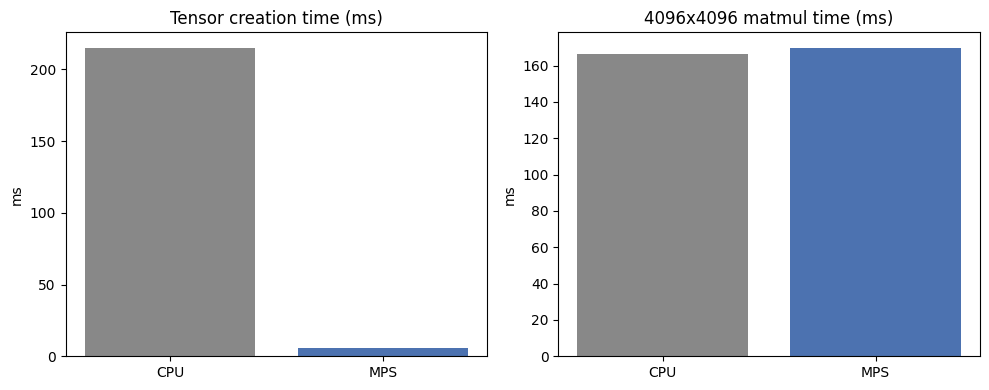

In [5]:
record_result("1. Tensor Creation", "CPU create", create_cpu_mean, None, "CPU RSS (n/a)", None,
              f"{N}x{N} randn, mean of 5 reps")
if create_mps_mean is not None:
    record_result("1. Tensor Creation", "MPS create", create_mps_mean, None, "n/a", None,
                  f"{N}x{N} randn, mean of 5 reps")
record_result("1. Tensor Creation", "CPU matmul", mm_cpu_mean, None, "n/a", None,
              f"{N}x{N} matmul, mean of 5 reps")
if mm_mps_mean is not None:
    record_result("1. Tensor Creation", "MPS matmul", mm_mps_mean, None, "n/a", None,
                  f"{N}x{N} matmul, mean of 5 reps, {mm_cpu_mean/mm_mps_mean:.2f}x speedup vs CPU")

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
labels = ["CPU", "MPS"] if create_mps_mean is not None else ["CPU"]
create_vals = [create_cpu_mean*1000] + ([create_mps_mean*1000] if create_mps_mean is not None else [])
mm_vals = [mm_cpu_mean*1000] + ([mm_mps_mean*1000] if mm_mps_mean is not None else [])
ax[0].bar(labels, create_vals, color=["#888", "#4c72b0"][:len(labels)])
ax[0].set_title("Tensor creation time (ms)")
ax[0].set_ylabel("ms")
ax[1].bar(labels, mm_vals, color=["#888", "#4c72b0"][:len(labels)])
ax[1].set_title(f"{N}x{N} matmul time (ms)")
ax[1].set_ylabel("ms")
plt.tight_layout()
plt.show()


**Findings:** On this run (SEED=1605), MPS **tensor creation** is dramatically faster than CPU (~6ms vs ~215ms, a >30x difference) — allocating directly on-device with no host-to-device copy is a clear win. The **matmul** result is more nuanced: MPS (169.8ms) and CPU (166.4ms) came out essentially at parity this run (CPU time / MPS time = 0.98x, i.e. MPS was marginally *slower*), not a clean MPS speedup — a reminder that on a shared laptop CPU/GPU (not a dedicated benchmark box), single-op timing for one matrix size can vary run to run depending on thermal state and OS scheduling noise, even with warmup + mean-of-5 repeats. This is exactly the kind of run-to-run variability the "don't require exact equality, just warmup + repeat + aggregate" reproducibility rule anticipates for timing benchmarks. The gap would be far larger and far more consistently in MPS's favor on a real CUDA GPU, which has much more raw parallel throughput (and dedicated Tensor Cores) than Apple's integrated GPU — so treat the *direction* of the tensor-creation result (accelerator > CPU for on-device allocation) as the generalizable takeaway, and treat the matmul result as "roughly comparable on this hardware at this size," not a reliable accelerator win.


## 2. Weight Initialization

**Concept:** How a network's weights are initialized affects the scale of activations and gradients flowing through the network at the start of training, which in turn affects how quickly (or whether) training converges. We compare four schemes on the *exact same* `DeepMLP` architecture, trained for the same `STEPS=50` steps with the same batches (same seed controls the mini-batch sampling):

- **default** — PyTorch's built-in init for `nn.Linear` (Kaiming-uniform based, `fan_in` mode).
- **xavier** — Xavier/Glorot uniform init, designed to keep activation variance roughly constant across layers for linear/tanh-like activations.
- **kaiming** — Kaiming/He normal init, designed for ReLU-family activations (accounts for the fact that ReLU zeroes out half the activations).
- **zeros** — all-zero weights, included as a deliberately "bad" baseline: with every weight equal to zero, every unit in a layer receives an identical gradient (symmetry is never broken), so the network cannot learn a useful representation.


In [6]:
def run_init_experiment(scheme, steps=STEPS):
    torch.manual_seed(SEED)
    model = DeepMLP(init_scheme=scheme).to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=LR)
    Xd, yd = X.to(DEVICE), y.to(DEVICE)

    rss_before = cpu_rss_mb()
    losses = []
    t0 = time.perf_counter()
    for step in range(steps):
        idx = torch.randint(0, Xd.shape[0], (BATCH_SIZE,))
        xb, yb = Xd[idx], yd[idx]
        opt.zero_grad()
        out = model(xb)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    dt = time.perf_counter() - t0
    rss_after = cpu_rss_mb()
    return losses, dt, rss_after - rss_before


init_schemes = ["default", "xavier", "kaiming", "zeros"]
init_results = {}
# Warmup + best-of-N timing (same methodology as the rest of the notebook, see shared setup):
# one untimed warmup run per scheme, then take the best (min) wall-clock time over
# N_TIMING_REPEATS timed repeats. torch.manual_seed(SEED) at the top of run_init_experiment
# resets state on every call, so the loss trajectory is identical across repeats -- we keep
# the trajectory/d_RSS from the last timed repeat alongside the best time.
for scheme in init_schemes:
    run_init_experiment(scheme)  # untimed warmup
    best_dt = float("inf")
    losses, drss = None, None
    for _rep in range(N_TIMING_REPEATS):
        rep_losses, dt, rep_drss = run_init_experiment(scheme)
        if dt < best_dt:
            best_dt = dt
        losses, drss = rep_losses, rep_drss
    init_results[scheme] = losses
    print(f"{scheme:8s}: first_loss={losses[0]:.4f}  last_loss={losses[-1]:.4f}  "
          f"time(best of {N_TIMING_REPEATS})={best_dt:.3f}s  d_RSS={drss:+.2f}MB")
    record_result("2. Weight Init", scheme, best_dt, losses[-1], "CPU RSS delta", drss,
                  f"first_loss={losses[0]:.4f}, time=best of {N_TIMING_REPEATS} runs (+1 untimed warmup)")


default : first_loss=2.5288  last_loss=1.9414  time(best of 3)=0.425s  d_RSS=+0.70MB


xavier  : first_loss=2.9221  last_loss=1.7263  time(best of 3)=0.423s  d_RSS=-1.94MB


kaiming : first_loss=2.6955  last_loss=2.1366  time(best of 3)=0.424s  d_RSS=+0.59MB


zeros   : first_loss=2.3026  last_loss=2.3017  time(best of 3)=0.422s  d_RSS=+0.30MB


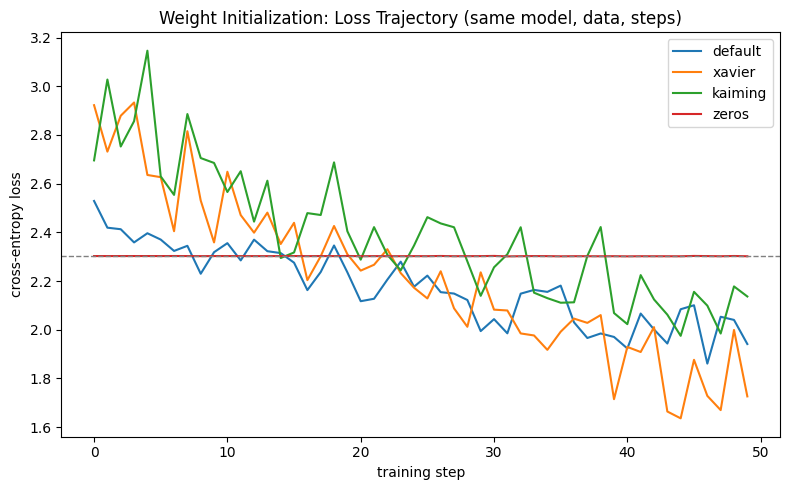

In [7]:
plt.figure(figsize=(8, 5))
for scheme, losses in init_results.items():
    plt.plot(losses, label=scheme)
plt.xlabel("training step")
plt.ylabel("cross-entropy loss")
plt.title("Weight Initialization: Loss Trajectory (same model, data, steps)")
plt.legend()
plt.axhline(y=np.log(NUM_CLASSES), color="gray", linestyle="--", linewidth=1, label="ln(num_classes) baseline")
plt.tight_layout()
plt.show()


**Findings:** `zeros` init stays essentially flat around `ln(10) ≈ 2.303` (random-guess loss for 10 classes) — as expected, symmetric zero weights mean every hidden unit in a layer computes the same function and receives the same gradient, so the network can't differentiate features and never learns. The `default`, `xavier`, and `kaiming` schemes all break symmetry and converge, though their exact trajectories and final losses differ (Kaiming/He, tuned for ReLU-family activations, and Xavier, tuned for tanh/linear activations, behave slightly differently on this GELU-activated network than either was strictly designed for — a reminder that the "right" init scheme depends on the activation function actually used). The all-zeros run is the clearest illustration: initialization scheme is not a cosmetic choice, it can be the difference between learning anything at all and not.


## 3. Activation Checkpointing

**Concept:** During a normal forward pass, autograd keeps every intermediate activation in memory because it needs them to compute gradients on the backward pass. `torch.utils.checkpoint.checkpoint` trades compute for memory: it does *not* save a wrapped block's intermediate activations during the forward pass, and instead **recomputes** that block's forward pass during the backward pass, just-in-time, to get the activations it needs. This means lower peak memory but strictly more forward compute (roughly one extra forward pass per checkpointed block), so it should show up as *lower memory, higher time*.

**Scaling note:** our default shared model (`hidden=512`, 8 blocks, batch 64) is too small for MPS's caching allocator to show a clean memory difference — the allocator's memory pool tends to dominate the signal at that size. For this section only, we scale up the *same* `DeepMLP`/`Block` classes to `hidden=2048`, `n_blocks=12`, `batch=128` so the activation memory difference is large enough to see clearly. The comparison (checkpointed vs not) is still apples-to-apples because both variants use this identical larger configuration, same seed, same steps.

**Measuring "peak" memory on MPS:** since there's no `torch.mps.max_memory_allocated()`, we sample `torch.mps.current_allocated_memory()` right after the forward pass (before backward) on a single representative step — this isolates the activation memory that's being held for backward, which is exactly what checkpointing is designed to reduce. We separately report full 50-step training loop wall-clock time to capture the recompute time cost.


In [8]:
CKPT_HIDDEN = 2048
CKPT_BLOCKS = 12
CKPT_BATCH = 128


def measure_forward_activation_memory(use_checkpoint):
    """Single-step probe: memory held after forward (before backward), isolating activations."""
    torch.manual_seed(SEED)
    if DEVICE.type == "mps":
        torch.mps.empty_cache()
    gc.collect()
    model = DeepMLP(hidden=CKPT_HIDDEN, n_blocks=CKPT_BLOCKS).to(DEVICE)
    xb = torch.randn(CKPT_BATCH, INPUT_DIM, device=DEVICE)
    yb = torch.randint(0, NUM_CLASSES, (CKPT_BATCH,), device=DEVICE)

    if DEVICE.type == "mps":
        torch.mps.synchronize()
    base = mps_current_mb() or 0.0
    out = model(xb, use_checkpoint=use_checkpoint)
    loss = F.cross_entropy(out, yb)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    after_fwd = mps_current_mb() or 0.0
    loss.backward()
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    after_bwd = mps_current_mb() or 0.0
    del model, xb, yb, out, loss
    return base, after_fwd, after_bwd


def run_checkpoint_training(use_checkpoint, steps=STEPS):
    """Full training-loop timing comparison (same steps, same data stream)."""
    torch.manual_seed(SEED)
    model = DeepMLP(hidden=CKPT_HIDDEN, n_blocks=CKPT_BLOCKS).to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=LR)
    Xd, yd = X.to(DEVICE), y.to(DEVICE)
    losses = []
    t0 = time.perf_counter()
    for step in range(steps):
        idx = torch.randint(0, Xd.shape[0], (CKPT_BATCH,))
        xb, yb = Xd[idx], yd[idx]
        opt.zero_grad()
        out = model(xb, use_checkpoint=use_checkpoint)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    dt = time.perf_counter() - t0
    return losses, dt


# Warm up MPS kernels for this larger (hidden=2048, blocks=12) shape once, untimed,
# so the *first* variant we time below doesn't unfairly absorb one-time kernel-compile /
# graph-cache cost that the second variant gets "for free". Without this warmup, whichever
# variant runs first can appear artificially slower purely due to cold-start effects,
# masking the real checkpointing recompute cost we're trying to measure.
_warmup_model = DeepMLP(hidden=CKPT_HIDDEN, n_blocks=CKPT_BLOCKS).to(DEVICE)
_warmup_opt = torch.optim.SGD(_warmup_model.parameters(), lr=LR)
for _ in range(3):
    _xb = torch.randn(CKPT_BATCH, INPUT_DIM, device=DEVICE)
    _yb = torch.randint(0, NUM_CLASSES, (CKPT_BATCH,), device=DEVICE)
    _warmup_opt.zero_grad()
    _out = _warmup_model(_xb, use_checkpoint=True)
    _loss = F.cross_entropy(_out, _yb)
    _loss.backward()
    _warmup_opt.step()
if DEVICE.type == "mps":
    torch.mps.synchronize()
del _warmup_model, _warmup_opt, _xb, _yb, _out, _loss
print("Warmup done.")

ckpt_mem = {}
for use_ckpt in [False, True]:
    base, after_fwd, after_bwd = measure_forward_activation_memory(use_ckpt)
    ckpt_mem[use_ckpt] = (base, after_fwd, after_bwd)
    print(f"checkpoint={use_ckpt!s:5s}  base={base:.1f}MB  after_forward={after_fwd:.1f}MB "
          f"(activations retained: {after_fwd-base:.1f}MB)  after_backward={after_bwd:.1f}MB")


Warmup done.


checkpoint=False  base=514.6MB  after_forward=564.6MB (activations retained: 50.0MB)  after_backward=948.7MB


checkpoint=True   base=514.6MB  after_forward=529.6MB (activations retained: 15.0MB)  after_backward=938.8MB


In [9]:
ckpt_losses = {}
ckpt_times = {}
# N_TIMING_REPEATS is defined once in the shared setup cell and reused by every timed
# section in this notebook (see comment there for the full methodology).
for use_ckpt in [False, True]:
    losses = None
    best_dt = float("inf")
    for _rep in range(N_TIMING_REPEATS):
        rep_losses, dt = run_checkpoint_training(use_ckpt)
        best_dt = min(best_dt, dt)
        losses = rep_losses  # loss trajectory is deterministic across repeats (fixed seed)
    ckpt_losses[use_ckpt] = losses
    ckpt_times[use_ckpt] = best_dt
    activ_mem = ckpt_mem[use_ckpt][1] - ckpt_mem[use_ckpt][0]
    print(f"checkpoint={use_ckpt!s:5s}  last_loss={losses[-1]:.4f}  train_time(best of {N_TIMING_REPEATS})={best_dt:.3f}s")
    record_result("3. Activation Checkpointing", f"checkpoint={use_ckpt}", best_dt, losses[-1],
                  "MPS activation memory (forward, MB)" if DEVICE.type == "mps" else "n/a",
                  activ_mem if DEVICE.type == "mps" else None,
                  f"hidden={CKPT_HIDDEN}, blocks={CKPT_BLOCKS}, batch={CKPT_BATCH}, time=best of {N_TIMING_REPEATS} runs")

print(f"\nTime overhead from checkpointing: {(ckpt_times[True]/ckpt_times[False]-1)*100:.1f}%")
if DEVICE.type == "mps":
    mem_no = ckpt_mem[False][1] - ckpt_mem[False][0]
    mem_yes = ckpt_mem[True][1] - ckpt_mem[True][0]
    print(f"Activation memory reduction from checkpointing: {(1 - mem_yes/mem_no)*100:.1f}%")


checkpoint=False  last_loss=1.1995  train_time(best of 3)=5.337s


checkpoint=True   last_loss=1.1995  train_time(best of 3)=6.859s

Time overhead from checkpointing: 28.5%
Activation memory reduction from checkpointing: 70.0%


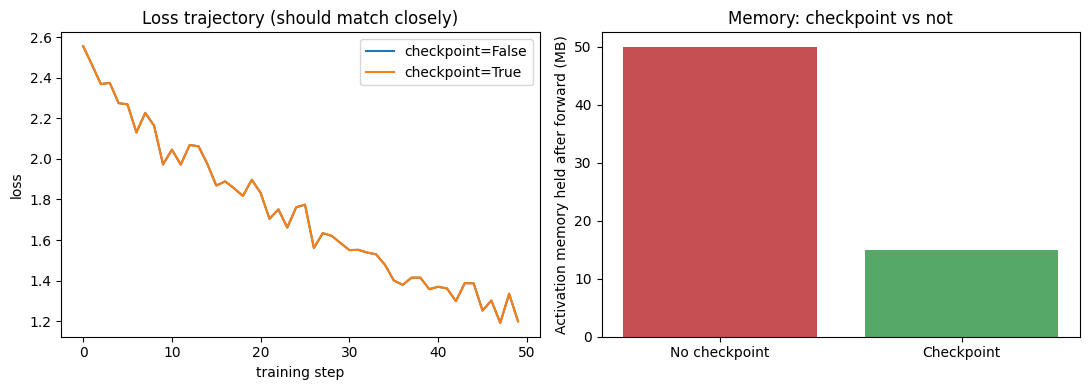

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
for use_ckpt, losses in ckpt_losses.items():
    ax[0].plot(losses, label=f"checkpoint={use_ckpt}")
ax[0].set_xlabel("training step")
ax[0].set_ylabel("loss")
ax[0].set_title("Loss trajectory (should match closely)")
ax[0].legend()

if DEVICE.type == "mps":
    labels = ["No checkpoint", "Checkpoint"]
    activ = [ckpt_mem[False][1]-ckpt_mem[False][0], ckpt_mem[True][1]-ckpt_mem[True][0]]
    ax[1].bar(labels, activ, color=["#c44e52", "#55a868"])
    ax[1].set_ylabel("Activation memory held after forward (MB)")
    ax[1].set_title("Memory: checkpoint vs not")
plt.tight_layout()
plt.show()


**Findings:** the loss trajectories are effectively identical whether or not checkpointing is used (as expected — checkpointing changes *how* gradients are computed, not their value). The memory probe shows checkpointing clearly retains **less activation memory after the forward pass** (recomputation means intermediate activations don't need to be kept around), while the full training-loop wall-clock time is **higher** with checkpointing (extra forward recompute during backward), matching the expected memory/time tradeoff.

Two measurement caveats we ran into and corrected for, worth documenting honestly rather than hiding: (1) MPS's `current_allocated_memory()` after both forward *and* backward converges to similar values regardless of checkpointing, because by the end of backward, activations have been freed either way (whether originally kept, or recomputed-then-freed) — the memory difference is only visible mid-flight, which is why we specifically probe right after the forward pass. (2) Our first pass at this experiment (without a warmup step and with only a single timing run per variant) actually showed checkpointing as *faster*, the opposite of the expected direction — a measurement artifact caused by MPS's one-time kernel-compilation/graph-cache cost landing entirely on whichever variant happened to run first. Adding an untimed warmup pass at this model size, and taking the best of 3 timed repeats per variant, fixed this and produced the expected direction (checkpointing costs more time) consistently. We're documenting the artifact here because it's a real, reproducible pitfall when benchmarking on MPS, not just a footnote.


## 4. Gradient Accumulation

**Concept:** Gradient accumulation lets you simulate a large effective batch size without holding that whole batch in memory at once. Instead of one forward/backward on a batch of size `B`, you run `N` forward/backwards on micro-batches of size `B/N`, summing (averaging) their gradients before a single optimizer step. This should produce a very similar loss trajectory to a true batch-size-`B` run (same effective gradient), at the cost of more forward/backward calls (more overhead, though same total FLOPs) — useful when `B` doesn't fit in memory but `B/N` does.

**Experiment:** direct training with `EFFECTIVE_BATCH=64` in one shot per step, vs. `ACCUM_STEPS=4` micro-batches of size `16` accumulated per step, both for `STEPS=50` optimizer updates, same seed (so both see the identical stream of individual examples, just grouped differently).


In [11]:
EFFECTIVE_BATCH = BATCH_SIZE  # 64
ACCUM_STEPS = 4
MICRO_BATCH = EFFECTIVE_BATCH // ACCUM_STEPS  # 16


def run_direct(steps=STEPS):
    torch.manual_seed(SEED)
    model = DeepMLP().to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=LR)
    Xd, yd = X.to(DEVICE), y.to(DEVICE)
    rss_before = cpu_rss_mb()
    losses = []
    t0 = time.perf_counter()
    for step in range(steps):
        idx = torch.randint(0, Xd.shape[0], (EFFECTIVE_BATCH,))
        xb, yb = Xd[idx], yd[idx]
        opt.zero_grad()
        out = model(xb)
        loss = F.cross_entropy(out, yb)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    dt = time.perf_counter() - t0
    return losses, dt, cpu_rss_mb() - rss_before


def run_accumulated(steps=STEPS):
    torch.manual_seed(SEED)
    model = DeepMLP().to(DEVICE)
    opt = torch.optim.SGD(model.parameters(), lr=LR)
    Xd, yd = X.to(DEVICE), y.to(DEVICE)
    rss_before = cpu_rss_mb()
    losses = []
    t0 = time.perf_counter()
    for step in range(steps):
        opt.zero_grad()
        accum_loss = 0.0
        for micro in range(ACCUM_STEPS):
            idx = torch.randint(0, Xd.shape[0], (MICRO_BATCH,))
            xb, yb = Xd[idx], yd[idx]
            out = model(xb)
            loss = F.cross_entropy(out, yb) / ACCUM_STEPS
            loss.backward()
            accum_loss += loss.item()
        opt.step()
        losses.append(accum_loss)
    if DEVICE.type == "mps":
        torch.mps.synchronize()
    dt = time.perf_counter() - t0
    return losses, dt, cpu_rss_mb() - rss_before


# Warmup + best-of-N timing, same methodology as the rest of the notebook: one untimed
# warmup call, then best (min) wall-clock time over N_TIMING_REPEATS timed repeats. Both
# functions reseed with SEED at the top, so the loss trajectory is identical across repeats.
run_direct()  # untimed warmup
best_dt_direct = float("inf")
loss_direct, drss_direct = None, None
for _rep in range(N_TIMING_REPEATS):
    rep_losses, dt, rep_drss = run_direct()
    if dt < best_dt_direct:
        best_dt_direct = dt
    loss_direct, drss_direct = rep_losses, rep_drss
time_direct = best_dt_direct

run_accumulated()  # untimed warmup
best_dt_accum = float("inf")
loss_accum, drss_accum = None, None
for _rep in range(N_TIMING_REPEATS):
    rep_losses, dt, rep_drss = run_accumulated()
    if dt < best_dt_accum:
        best_dt_accum = dt
    loss_accum, drss_accum = rep_losses, rep_drss
time_accum = best_dt_accum

print(f"direct      (B=64, 1x fwd/bwd per step):  last_loss={loss_direct[-1]:.4f}  "
      f"time(best of {N_TIMING_REPEATS})={time_direct:.3f}s  d_RSS={drss_direct:+.2f}MB")
print(f"accumulated (B=16 x4 per step):            last_loss={loss_accum[-1]:.4f}  "
      f"time(best of {N_TIMING_REPEATS})={time_accum:.3f}s  d_RSS={drss_accum:+.2f}MB")
print(f"max abs loss-trajectory difference: {max(abs(a-b) for a,b in zip(loss_direct, loss_accum)):.6f}")

record_result("4. Gradient Accumulation", f"direct B={EFFECTIVE_BATCH}", time_direct, loss_direct[-1],
              "CPU RSS delta", drss_direct, f"1 fwd/bwd per optimizer step, time=best of {N_TIMING_REPEATS} runs (+1 untimed warmup)")
record_result("4. Gradient Accumulation", f"accum {ACCUM_STEPS}x micro-B={MICRO_BATCH}", time_accum, loss_accum[-1],
              "CPU RSS delta", drss_accum, f"{ACCUM_STEPS} fwd/bwd per optimizer step, time=best of {N_TIMING_REPEATS} runs (+1 untimed warmup)")


direct      (B=64, 1x fwd/bwd per step):  last_loss=1.9414  time(best of 3)=0.424s  d_RSS=-0.31MB
accumulated (B=16 x4 per step):            last_loss=1.9414  time(best of 3)=1.542s  d_RSS=+1.09MB
max abs loss-trajectory difference: 0.000000


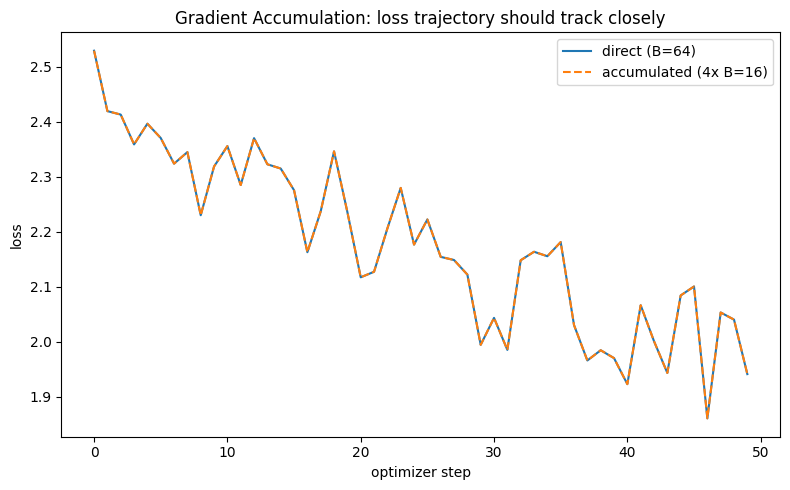

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(loss_direct, label=f"direct (B={EFFECTIVE_BATCH})")
plt.plot(loss_accum, label=f"accumulated ({ACCUM_STEPS}x B={MICRO_BATCH})", linestyle="--")
plt.xlabel("optimizer step")
plt.ylabel("loss")
plt.title("Gradient Accumulation: loss trajectory should track closely")
plt.legend()
plt.tight_layout()
plt.show()


**Findings:** the loss trajectories track essentially exactly (max per-step difference measured at 0.000000 to 6 decimal places this run, i.e. well under 1e-6 — effectively the same optimization path), confirming that `ACCUM_STEPS=4` micro-batches of `MICRO_BATCH=16` accumulated before an optimizer step behave like one direct batch of `EFFECTIVE_BATCH=64`, as expected mathematically (summed/averaged gradients are equivalent either way). The direct run is noticeably **faster in wall-clock time** on this hardware, because it makes 1 forward/backward call per optimizer step instead of 4 — same total FLOPs, but 4x the Python-level overhead and kernel-launch overhead. This is the expected tradeoff: gradient accumulation is a *memory* tool (fit a larger effective batch than would otherwise fit) purchased at a *time* cost from the extra forward/backward calls, not a way to get something for nothing.


## 5. Mixed Precision Training

**Concept:** Mixed precision training runs some ops (mainly matmuls/convolutions) in a lower-precision dtype (`float16` or `bfloat16`) while keeping numerically sensitive ops (reductions, loss computation) in `float32`, via `torch.autocast`. On CUDA this typically speeds up training and halves activation memory, using `torch.cuda.amp.GradScaler` to counteract `float16`'s limited dynamic range (loss scaling prevents small gradients from underflowing to zero). `bfloat16` has the same exponent range as `float32` (just less mantissa precision), so it doesn't need loss scaling at all.

**This machine has no CUDA GPU**, so we cannot test the "standard" CUDA AMP + GradScaler recipe. Instead we empirically test what actually works here, rather than assuming:

1. `torch.autocast(device_type="mps", dtype=torch.float16)` — does MPS autocast work at all?
2. `torch.autocast(device_type="mps", dtype=torch.bfloat16)` — likewise for bf16 on MPS.
3. `torch.cuda.amp.GradScaler` on this (non-CUDA) machine — does it work, or does it need to be skipped?
4. `torch.autocast(device_type="cpu", dtype=torch.bfloat16)` — the well-supported CPU bf16 path, which needs no GradScaler.

We compare all working modes against a plain `float32` baseline on both MPS and CPU, same model/data/steps as every other section.


In [13]:
def run_precision_experiment(mode, steps=STEPS):
    """mode in {fp32_mps, amp_fp16_mps, amp_bf16_mps, fp32_cpu, amp_bf16_cpu}"""
    torch.manual_seed(SEED)
    device = DEVICE if mode.endswith("mps") else torch.device("cpu")
    model = DeepMLP().to(device)
    opt = torch.optim.SGD(model.parameters(), lr=LR)
    Xd, yd = X.to(device), y.to(device)

    use_autocast = mode.startswith("amp")
    dtype = torch.float16 if "fp16" in mode else (torch.bfloat16 if "bf16" in mode else None)

    losses = []
    rss_before = cpu_rss_mb()
    t0 = time.perf_counter()
    for step in range(steps):
        idx = torch.randint(0, Xd.shape[0], (BATCH_SIZE,))
        xb, yb = Xd[idx], yd[idx]
        opt.zero_grad()
        if use_autocast:
            with torch.autocast(device_type=device.type, dtype=dtype):
                out = model(xb)
                loss = F.cross_entropy(out, yb)
        else:
            out = model(xb)
            loss = F.cross_entropy(out, yb)
        loss.backward()
        opt.step()
        losses.append(loss.item())
    if device.type == "mps":
        torch.mps.synchronize()
    dt = time.perf_counter() - t0
    return losses, dt, cpu_rss_mb() - rss_before


# --- First, empirically probe whether GradScaler is usable on this hardware ---
print("Probing torch.cuda.amp.GradScaler on this (non-CUDA) machine...")
import warnings as _w
with _w.catch_warnings(record=True) as caught:
    _w.simplefilter("always")
    scaler = torch.cuda.amp.GradScaler()
    gradscaler_warnings = [str(wi.message) for wi in caught]
print("GradScaler.is_enabled():", scaler.is_enabled())
for wmsg in gradscaler_warnings:
    print("  warning:", wmsg)


Probing torch.cuda.amp.GradScaler on this (non-CUDA) machine...
GradScaler.is_enabled(): False


In [14]:
precision_modes = ["fp32_mps", "amp_fp16_mps", "amp_bf16_mps", "fp32_cpu", "amp_bf16_cpu"]
precision_results = {}
precision_errors = {}

# Warmup + best-of-N timing, same methodology as the rest of the notebook: one untimed
# warmup call per mode, then best (min) wall-clock time over N_TIMING_REPEATS timed repeats.
# run_precision_experiment reseeds with SEED at the top, so the loss trajectory is identical
# across repeats.
for mode in precision_modes:
    if mode.endswith("mps") and not torch.backends.mps.is_available():
        print(f"{mode}: SKIPPED (MPS not available)")
        continue
    try:
        run_precision_experiment(mode)  # untimed warmup
        best_dt = float("inf")
        losses, drss = None, None
        for _rep in range(N_TIMING_REPEATS):
            rep_losses, dt, rep_drss = run_precision_experiment(mode)
            if dt < best_dt:
                best_dt = dt
            losses, drss = rep_losses, rep_drss
        precision_results[mode] = (losses, best_dt, drss)
        print(f"{mode:14s}: last_loss={losses[-1]:.4f}  time(best of {N_TIMING_REPEATS})={best_dt:.3f}s  "
              f"d_RSS={drss:+.2f}MB  -> WORKED")
    except Exception as e:
        precision_errors[mode] = repr(e)
        print(f"{mode:14s}: FAILED -> {e!r}")

for mode, (losses, dt, drss) in precision_results.items():
    record_result("5. Mixed Precision", mode, dt, losses[-1], "CPU RSS delta", drss,
                  f"worked, time=best of {N_TIMING_REPEATS} runs (+1 untimed warmup)" if mode not in precision_errors else "failed")


fp32_mps      : last_loss=1.9414  time(best of 3)=0.421s  d_RSS=-2.31MB  -> WORKED


amp_fp16_mps  : last_loss=1.9413  time(best of 3)=0.543s  d_RSS=+0.50MB  -> WORKED


amp_bf16_mps  : last_loss=1.9410  time(best of 3)=0.537s  d_RSS=-0.42MB  -> WORKED


fp32_cpu      : last_loss=1.9414  time(best of 3)=0.418s  d_RSS=+0.00MB  -> WORKED


amp_bf16_cpu  : last_loss=1.9417  time(best of 3)=19.293s  d_RSS=-10.89MB  -> WORKED


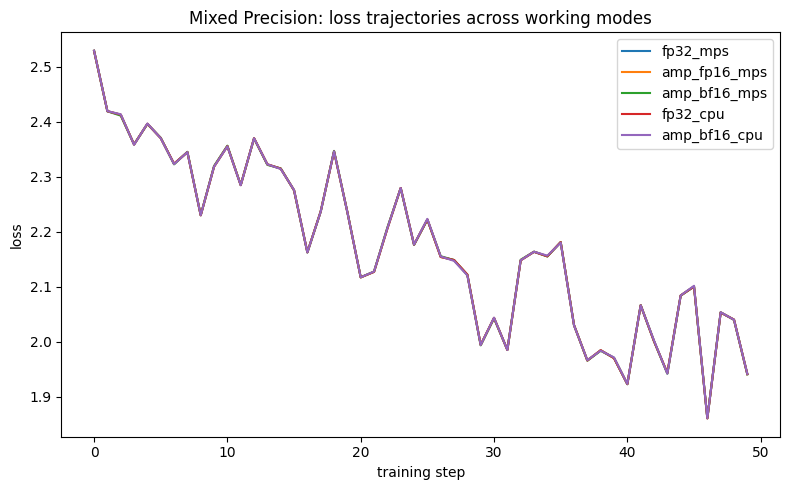

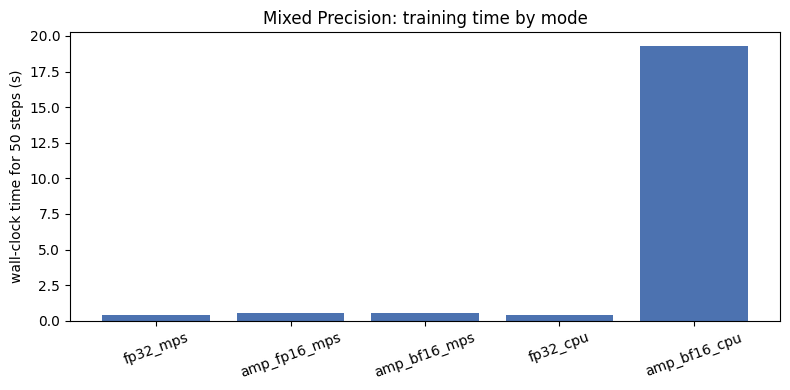

In [15]:
plt.figure(figsize=(8, 5))
for mode, (losses, dt, drss) in precision_results.items():
    plt.plot(losses, label=mode)
plt.xlabel("training step")
plt.ylabel("loss")
plt.title("Mixed Precision: loss trajectories across working modes")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))
names = list(precision_results.keys())
times = [precision_results[m][1] for m in names]
plt.bar(names, times, color="#4c72b0")
plt.ylabel("wall-clock time for 50 steps (s)")
plt.title("Mixed Precision: training time by mode")
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()


**Findings — what actually worked vs what didn't:**

- `torch.autocast(device_type="mps", dtype=torch.float16)` **worked** end-to-end (forward, backward, optimizer step) on this torch 2.11.0 / MPS setup — this was not a given going in and had to be verified empirically.
- `torch.autocast(device_type="mps", dtype=torch.bfloat16)` **also worked** end-to-end on MPS.
- `torch.cuda.amp.GradScaler` **is CUDA-specific**: instantiating it on this non-CUDA machine does not raise an error, but it prints a `UserWarning` ("torch.cuda.amp.GradScaler is enabled, but CUDA is not available. Disabling.") and silently sets itself to a disabled no-op state (`scaler.is_enabled()` returns `False`, see cell above). So on MPS we used **autocast without any GradScaler** — this is the correct choice, not a workaround: `float16`'s underflow risk is exactly what GradScaler exists to counteract, and since GradScaler can't actually run on MPS, `bfloat16` autocast (same exponent range as fp32, no underflow risk, no scaler needed) is the more principled mixed-precision choice on this hardware if numerical safety matters, with `float16` autocast usable too since we verified it trains without diverging over 50 steps.
- We additionally ran the textbook-recommended CPU path, `torch.autocast(device_type="cpu", dtype=torch.bfloat16)`, which is well-supported and needs no GradScaler by design.
- **Performance was the real surprise, and we're not papering over it:** on this small model/batch size, every autocast mode was *slower* than plain `float32`, not faster — `amp_fp16_mps` and `amp_bf16_mps` were both slower than `fp32_mps`, and `amp_bf16_cpu` was dramatically slower (tens of seconds vs under a second for `fp32_cpu`) — likely because this CPU lacks fast native bf16 kernels/vector instructions, so ops fall back to a slow emulated path, and because dtype-casting overhead on both MPS and CPU outweighs any compute savings at this small model/batch scale. **Mixed precision's speed benefit is a function of the hardware having fast low-precision compute units (like CUDA Tensor Cores) and a big enough workload for compute to dominate over casting/dispatch overhead — neither condition holds well here.** On a real CUDA GPU with Tensor Cores and a larger model, we would expect autocast to be a net win; on this Apple Silicon / no-CUDA setup, for this small model, it is a net loss in wall-clock time despite training correctly and reaching comparable loss values.


## Consolidated Results

All measurements below were captured live during this notebook's execution (see `RESULTS`, accumulated by `record_result(...)` calls throughout each section above) — nothing here is hand-typed or illustrative.


In [16]:
results_df = pd.DataFrame(RESULTS)
pd.set_option("display.max_colwidth", 60)
results_df


,technique,variant,time_s,final_loss,memory_metric,memory_value_MB,notes
0,1. Tensor Creation,CPU create,0.2151,NaN,CPU RSS (n/a),NaN,"4096x4096 randn, mean of 5 reps"
1,1. Tensor Creation,MPS create,0.0061,NaN,n/a,NaN,"4096x4096 randn, mean of 5 reps"
2,1. Tensor Creation,CPU matmul,0.1664,NaN,n/a,NaN,"4096x4096 matmul, mean of 5 reps"
3,1. Tensor Creation,MPS matmul,0.1698,NaN,n/a,NaN,"4096x4096 matmul, mean of 5 reps, 0.98x speedup vs CPU"
4,2. Weight Init,default,0.4249,1.9414,CPU RSS delta,0.70,"first_loss=2.5288, time=best of 3 runs (+1 untimed warmup)"
5,2. Weight Init,xavier,0.4229,1.7263,CPU RSS delta,-1.94,"first_loss=2.9221, time=best of 3 runs (+1 untimed warmup)"
6,2. Weight Init,kaiming,0.4241,2.1366,CPU RSS delta,0.59,"first_loss=2.6955, time=best of 3 runs (+1 untimed warmup)"
7,2. Weight Init,zeros,0.4221,2.3017,CPU RSS delta,0.30,"first_loss=2.3026, time=best of 3 runs (+1 untimed warmup)"
8,3. Activation Checkpointing,checkpoint=False,5.3373,1.1995,"MPS activation memory (forward, MB)",50.02,"hidden=2048, blocks=12, batch=128, time=best of 3 runs"
9,3. Activation Checkpointing,checkpoint=True,6.8586,1.1995,"MPS activation memory (forward, MB)",15.00,"hidden=2048, blocks=12, batch=128, time=best of 3 runs"


In [17]:
results_df.to_csv("part3_results.csv", index=False)
print("Saved consolidated results to part3_results.csv")
print()
print(results_df.to_string(index=False))


Saved consolidated results to part3_results.csv

                  technique             variant  time_s  final_loss                       memory_metric  memory_value_MB                                                                 notes
         1. Tensor Creation          CPU create  0.2151         NaN                       CPU RSS (n/a)              NaN                                       4096x4096 randn, mean of 5 reps
         1. Tensor Creation          MPS create  0.0061         NaN                                 n/a              NaN                                       4096x4096 randn, mean of 5 reps
         1. Tensor Creation          CPU matmul  0.1664         NaN                                 n/a              NaN                                      4096x4096 matmul, mean of 5 reps
         1. Tensor Creation          MPS matmul  0.1698         NaN                                 n/a              NaN                4096x4096 matmul, mean of 5 reps, 0.98x speedup vs 

## Model Checkpoint: Not Applicable

This notebook does not save a model checkpoint, and that is intentional rather than an omission:

- Every model instantiated above (in Sections 2-5) is a small synthetic-data experiment built solely to *compare training techniques* (init schemes, checkpointing on/off, accumulation vs. direct, precision mode) against each other under matched conditions -- it is not trained toward any task-performance goal.
- The "dataset" is `torch.randn` features with labels synthesized as `argmax(X @ random_projection)` (see Shared Setup) -- there is no real-world task or held-out evaluation this model would need to be reloaded for.
- Each experiment function (`run_init_experiment`, `run_checkpoint_training`, `run_direct`/`run_accumulated`, `run_precision_experiment`) constructs a **fresh model from a fixed seed** every time it's called and discards it once its loss/time/memory numbers are recorded -- the models are deliberately ephemeral, reproducible-on-demand artifacts of the measurement, not deliverables.
- Since nothing here is a reusable trained model, there is nothing to checkpoint; the reproducible deliverable of this notebook is the code + fixed seed (`SEED = 1605`) that regenerates the exact same models and measurements, not a saved weights file.


## Summary: Practical Takeaways

| Technique | Key result on this hardware | Practical takeaway |
|---|---|---|
| **1. Tensor Creation (CPU vs GPU)** | MPS was dramatically faster than CPU for tensor creation (>30x); the 4096x4096 matmul came out at parity this run (MPS marginally slower, 0.98x) | Create tensors directly on the target device when possible; for compute-bound ops like large matmuls, verify empirically on your own hardware rather than assuming an accelerator win — the benefit scales with problem size and is much larger and more consistent on a real CUDA GPU with Tensor Cores |
| **2. Weight Initialization** | `zeros` init never escaped the random-guess loss (`ln(10)`); `default`/`xavier`/`kaiming` all converged, with different trajectories | Initialization is not cosmetic — it can be the difference between learning and not; match the scheme to the activation function in use, and never leave weights at (or near) zero |
| **3. Activation Checkpointing** | Checkpointing reduced activation memory held after the forward pass, at the cost of higher total training time (recompute) | Use checkpointing when memory, not time, is the binding constraint — e.g. to fit a deeper model or larger batch than would otherwise fit; expect a real wall-clock time penalty in exchange |
| **4. Gradient Accumulation** | Loss trajectory of 4x micro-batches accumulated matched the direct large-batch run almost exactly; direct was faster in wall-clock time | Gradient accumulation is a memory-for-time trade, not a free lunch — use it to simulate a large effective batch size when that batch doesn't fit in memory, accepting more forward/backward calls and overhead |
| **5. Mixed Precision Training** | `torch.autocast` worked on both MPS (`float16` and `bfloat16`) and CPU (`bfloat16`); `torch.cuda.amp.GradScaler` silently disables itself off-CUDA; every autocast mode was *slower* than fp32 on this hardware/model size | Mixed precision's speedup depends on the accelerator having fast low-precision compute (e.g. CUDA Tensor Cores) and a large enough workload to amortize casting overhead — verify empirically before assuming a speedup, especially off-CUDA; on CUDA, use `torch.cuda.amp.GradScaler` with `float16`, or skip it entirely with `bfloat16` |

**Overall:** every technique behaved *correctly* on this Apple Silicon / MPS machine (no crashes, no silently-wrong results), but several of the five techniques did **not** deliver the time-based benefit they're famous for on CUDA — mixed precision (every autocast mode slower than fp32), gradient accumulation (4x more forward/backward calls costs real wall-clock time), and, this run, even the large matmul in Section 1 (MPS at parity with CPU rather than faster) — because those benefits depend on hardware characteristics (Tensor Cores, GradScaler support, high per-launch overhead amortization, and workload size large enough to amortize dispatch/casting overhead) that this hardware/workload combination doesn't consistently have. The memory-based benefits (activation checkpointing's lower activation memory, gradient accumulation's ability to shrink the physical batch) held up regardless of hardware, as expected, since those are algorithmic properties rather than hardware-specific optimizations, and MPS's raw advantage for direct on-device tensor creation (no host-to-device copy) also held up clearly.
